# 🏥 Diabetes Prediction: ML for Chronic Disease Early Detection

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting diabetes risk to support preventive health policy and clinical decision support  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting diabetes using clinical indicators (blood glucose, HbA1c, BMI) and health history (smoking, hypertension, heart disease). The model supports **population health screening** and **clinical decision support** for early intervention.

### Government Policy Context
- **Department of Health & Aged Care** — National Diabetes Strategy 2021-2030, Medicare Benefits Schedule analytics
- **AIHW (Australian Institute of Health & Welfare)** — National Health Survey, chronic disease surveillance
- **PBS (Pharmaceutical Benefits Scheme)** — Diabetes medication utilisation, cost forecasting
- **Primary Health Networks (PHNs)** — Chronic disease management, GP referral pathways
- **CSIRO** — Total Wellbeing Diet, precision health research

### Clinical Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| High diabetes risk | Urgent GP referral, pathology (OGTT, HbA1c) | GP + patient |
| Moderate risk | Lifestyle intervention program, 3-month follow-up | PHN care coordinator |
| Low risk (confident) | Annual screening, health promotion | Automated health check |
| Low risk (risk factors) | Targeted education (diet, exercise), 6-month follow-up | Practice nurse |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
print("Scanning /kaggle/input...")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            data_path = full_path
if data_path is None:
    raise FileNotFoundError("No CSV found")
with open(data_path, 'r') as fh:
    sample = fh.read(2048)
sep = ';' if sample.count(';') > sample.count(',') else ','
df = pd.read_csv(data_path, sep=sep)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Scanning /kaggle/input...
  Found: /kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv

Loaded: 100,000 rows x 9 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:30s} | {str(dtype):10s} | unique={nuniq:6d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. gender                         | object     | unique=     3 | nulls=  0 | eg: Female
   1. age                            | float64    | unique=   102 | nulls=  0 | eg: 80.0
   2. hypertension                   | int64      | unique=     2 | nulls=  0 | eg: 0
   3. heart_disease                  | int64      | unique=     2 | nulls=  0 | eg: 1
   4. smoking_history                | object     | unique=     6 | nulls=  0 | eg: never
   5. bmi                            | float64    | unique=  4247 | nulls=  0 | eg: 25.19
   6. HbA1c_level                    | float64    | unique=    18 | nulls=  0 | eg: 6.6
   7. blood_glucose_level            | int64      | unique=    18 | nulls=  0 | eg: 140
   8. diabetes                       | int64      | unique=     2 | nulls=  0 | eg: 0


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 2. Target Variable Identification & Analysis

In [4]:
target_candidates = ['diabetes', 'Diabetes', 'Outcome', 'outcome', 'Target', 'target',
                     'Class', 'class', 'Label', 'diagnosis']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break
if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")
if target_col is None:
    raise ValueError("Could not identify target")

if df[target_col].dtype == 'object':
    yes_kw = ['Yes', 'yes', 'Y', '1', 'Positive', 'positive', 'Diabetic']
    mapping = {v: (1 if v in yes_kw else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped: {mapping}")

print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
print(f"\nProportions:")
print(df[target_col].value_counts(normalize=True).sort_index().round(4))
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'diabetes'

Distribution:
diabetes
0    91500
1     8500
Name: count, dtype: int64

Proportions:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Imbalance ratio: 0.093


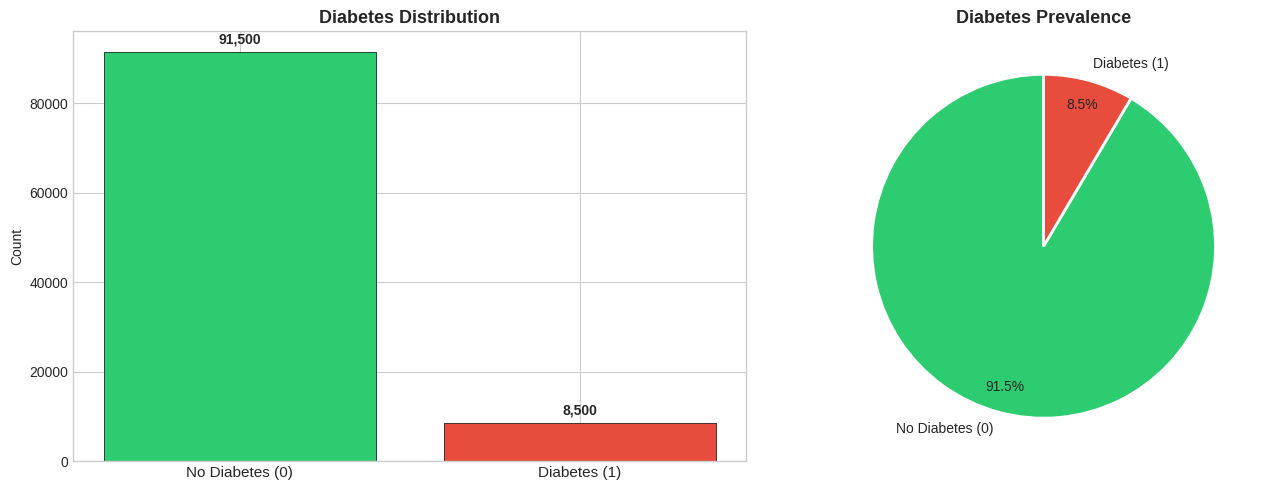

Australian context: ~1.3M Australians diagnosed with diabetes (AIHW 2023).
Type 2 diabetes accounts for ~85% of cases. Annual cost ~$14.6B to healthcare system.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = [f'Class {x}' for x in vc.index]
if len(vc) == 2 and set(vc.index) == {0, 1}:
    labels = ['No Diabetes (0)', 'Diabetes (1)']
colors = ['#2ecc71', '#e74c3c'] if len(vc) == 2 else sns.color_palette('husl', len(vc))
axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Diabetes Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, f'{v:,}', ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Diabetes Prevalence', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("Australian context: ~1.3M Australians diagnosed with diabetes (AIHW 2023).")
print("Type 2 diabetes accounts for ~85% of cases. Annual cost ~$14.6B to healthcare system.")


## 3. Exploratory Data Analysis

Key questions for health policy:
- Which clinical indicators most strongly predict diabetes?
- Are there clear diagnostic thresholds (HbA1c >= 6.5%, fasting glucose >= 7.0)?
- How do comorbidities (hypertension, heart disease) interact with diabetes risk?
- Do lifestyle factors (smoking, BMI) show dose-response relationships?


Numeric features (6): ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


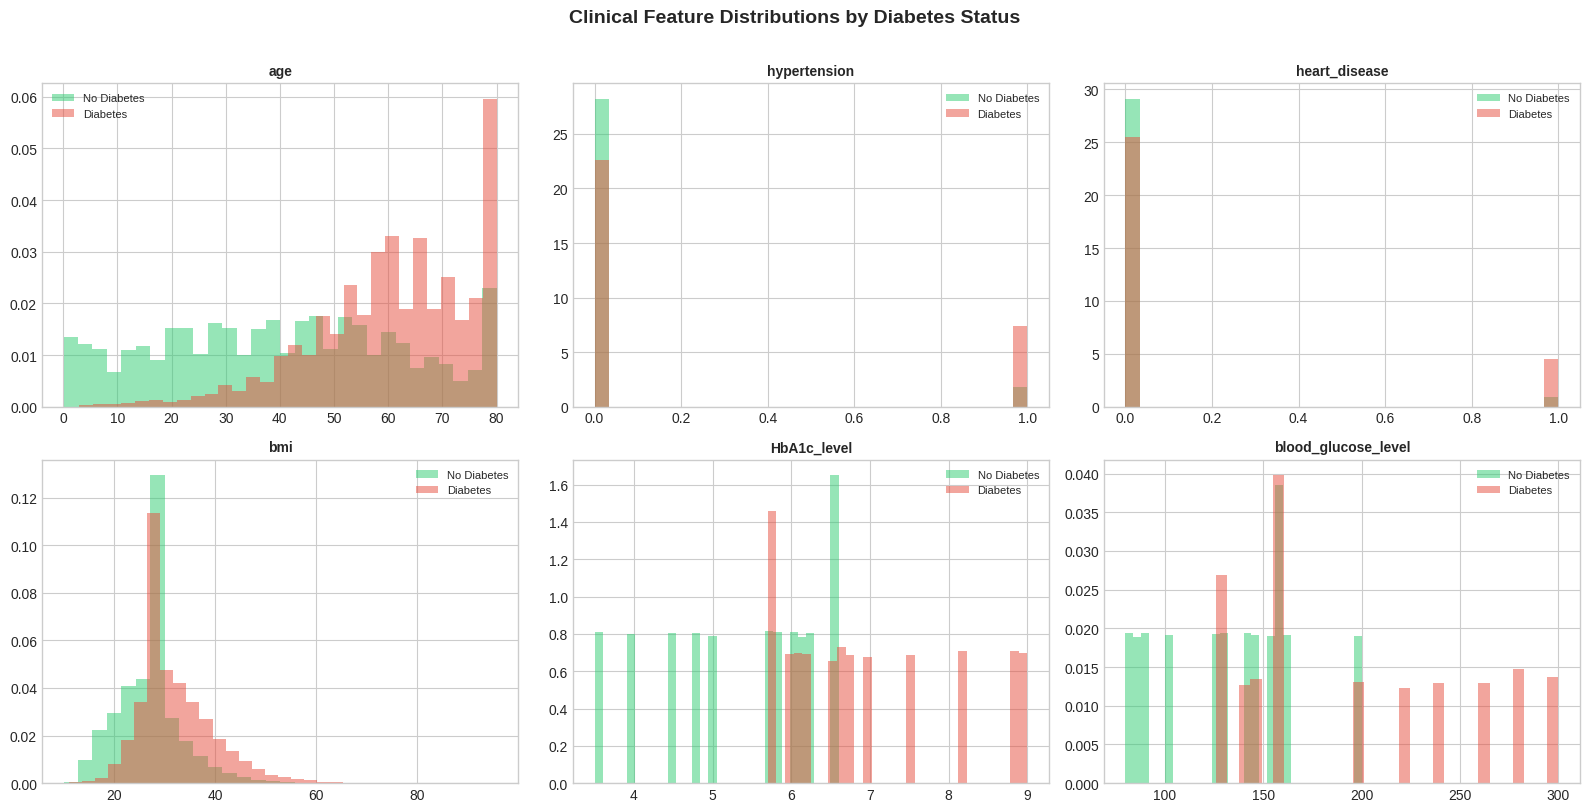

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['id', 'index']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

plot_cols = numeric_cols[:9]
if len(plot_cols) > 0:
    n_rows_p = (len(plot_cols) + 2) // 3
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for label, color, name in zip(sorted(df[target_col].unique()),
                                       ['#2ecc71', '#e74c3c'], ['No Diabetes', 'Diabetes']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=30, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].legend(fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Clinical Feature Distributions by Diabetes Status', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical: ['gender', 'smoking_history']
Binary numeric: ['hypertension', 'heart_disease']


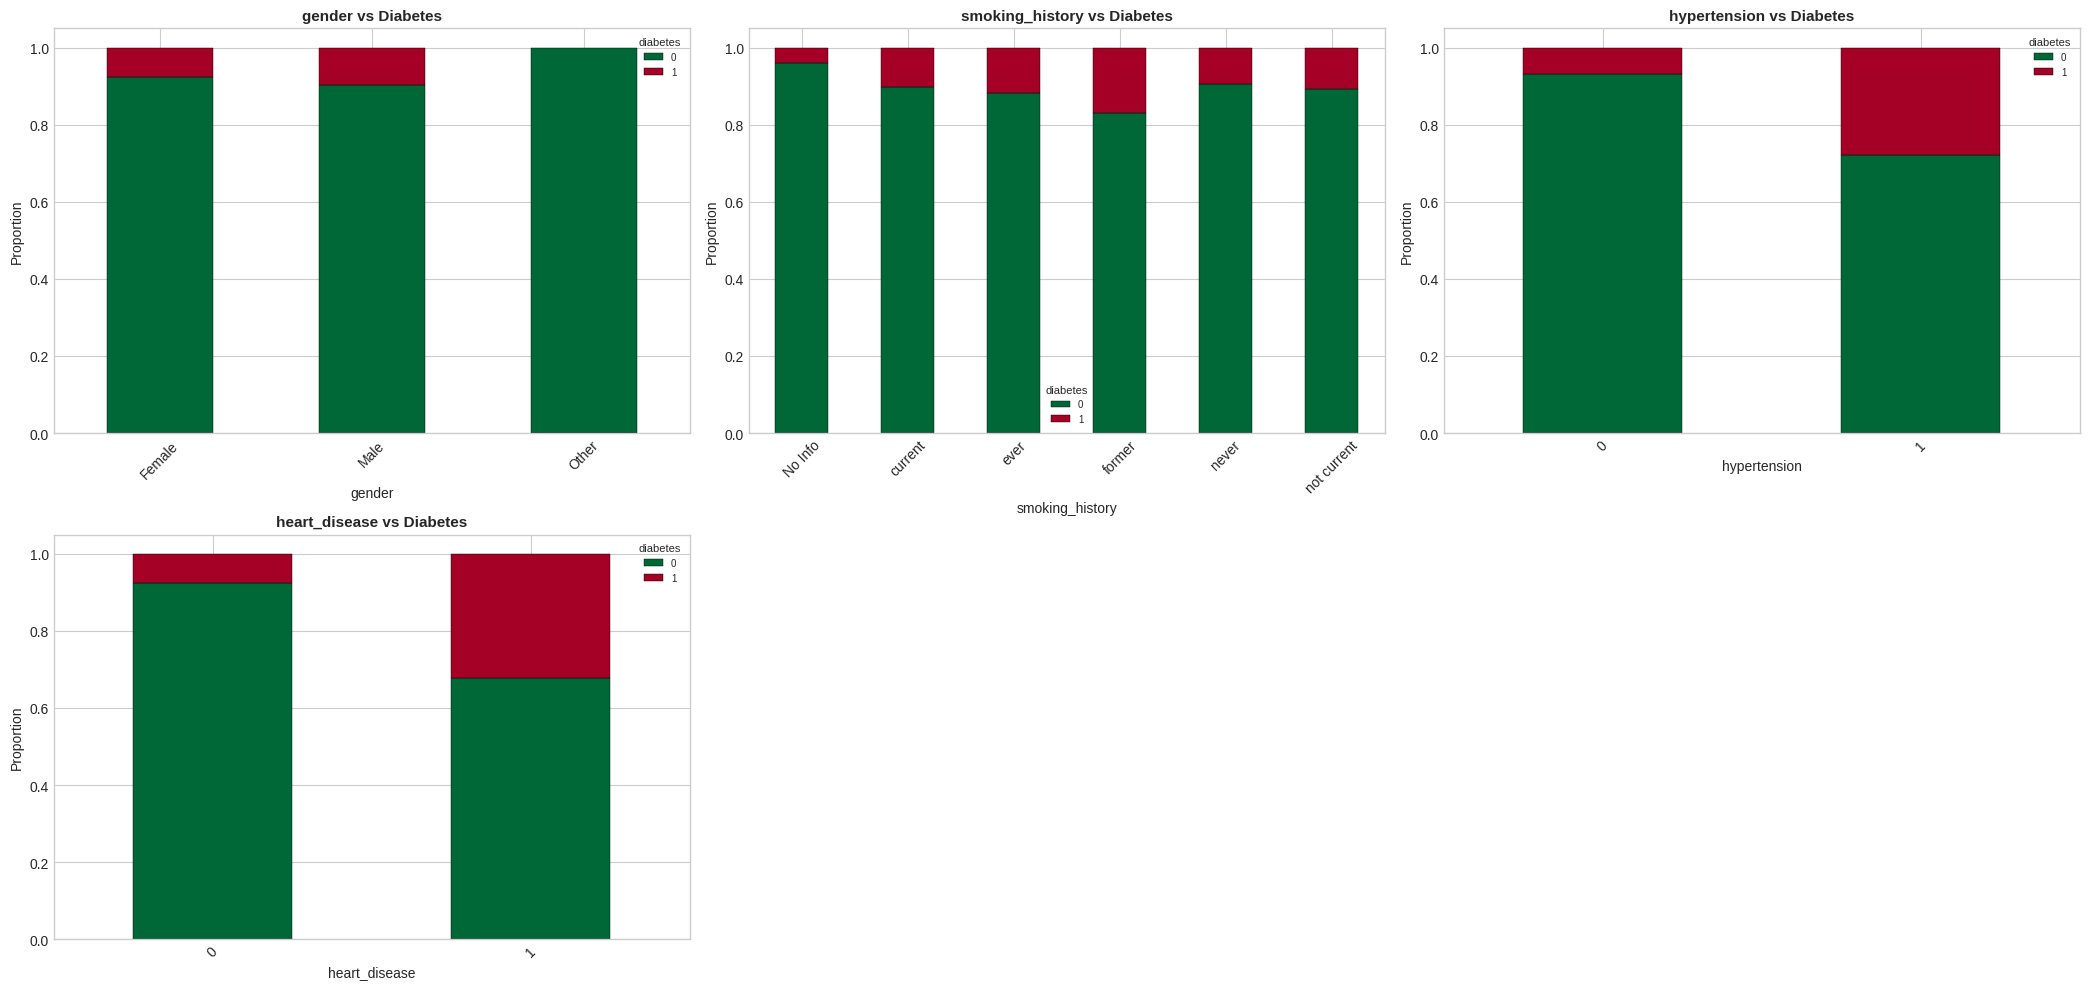

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 15]

# Also check binary numeric columns
binary_num = [c for c in numeric_cols if df[c].nunique() == 2]
print(f"Categorical: {cat_cols}")
print(f"Binary numeric: {binary_num}")

plot_cats = cat_cols + binary_num
plot_cats = plot_cats[:6]
if len(plot_cats) > 0:
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = (len(plot_cats) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='RdYlGn_r', edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Diabetes', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Proportion')
        axes[i].legend(title=target_col, fontsize=7, title_fontsize=8)
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


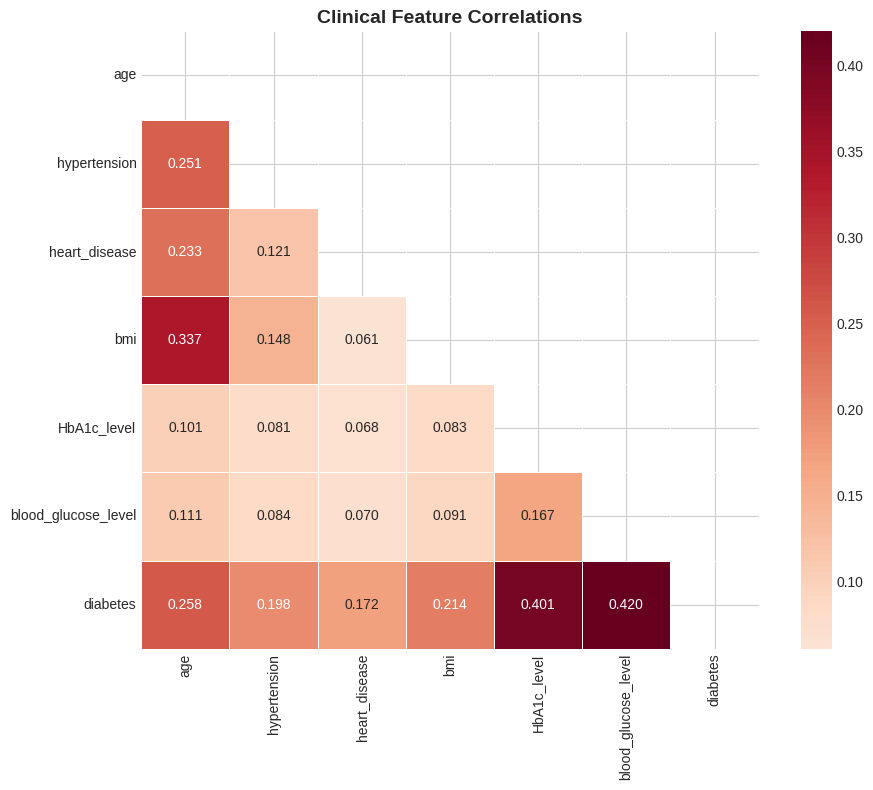

Correlations with diabetes:
  blood_glucose_level            +0.4196
  HbA1c_level                    +0.4007
  age                            +0.2580
  bmi                            +0.2144
  hypertension                   +0.1978
  heart_disease                  +0.1717


In [8]:
if len(numeric_cols) > 1:
    corr_cols = numeric_cols + [target_col]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Clinical Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Correlations with diabetes:")
    for feat, val in target_corr.items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:30s} {direction}{val:.4f}")


## 4. Feature Engineering & Preprocessing

Clinical risk models benefit from:
- **BMI categories** — WHO classification (underweight/normal/overweight/obese)
- **HbA1c diagnostic bands** — normal (<5.7%), pre-diabetic (5.7-6.4%), diabetic (>=6.5%)
- **Comorbidity count** — number of co-existing conditions
- **Age-BMI interaction** — older + higher BMI = compounding risk


In [9]:
df_model = df.copy()

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        n_q = (df_model[col] == '?').sum()
        if n_q > 0:
            df_model[col] = df_model[col].replace('?', np.nan)

drop_cols = [c for c in df_model.columns if c.lower() in ['id', 'index', 'unnamed: 0']]
if drop_cols:
    df_model.drop(columns=drop_cols, inplace=True)

le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values
assert len(np.unique(y)) >= 2
null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print(f"Imputing {null_counts.sum()} missing values...")
    X = X.fillna(X.median())
print(f"\nFeature matrix: {X.shape}")


  Encoded 'gender': 3 classes
  Encoded 'smoking_history': 6 classes

Feature matrix: (100000, 8)


In [10]:
feature_names = X.columns.tolist()
composites_added = []

# BMI category (WHO)
bmi_cols = [c for c in feature_names if 'bmi' in c.lower()]
if bmi_cols:
    X['bmi_category'] = pd.cut(X[bmi_cols[0]], bins=[0, 18.5, 25, 30, 999],
                                labels=[0, 1, 2, 3]).astype(float).fillna(1).astype(int)
    composites_added.append('bmi_category')
    print(f"Created 'bmi_category' (WHO: underweight/normal/overweight/obese)")

# HbA1c diagnostic band
hba1c_cols = [c for c in feature_names if 'hba1c' in c.lower() or 'a1c' in c.lower() or 'HbA1c' in c]
if hba1c_cols:
    X['hba1c_band'] = pd.cut(X[hba1c_cols[0]], bins=[0, 5.7, 6.5, 999],
                              labels=[0, 1, 2]).astype(float).fillna(0).astype(int)
    composites_added.append('hba1c_band')
    print(f"Created 'hba1c_band' (normal/pre-diabetic/diabetic range)")

# Blood glucose diagnostic flag
glucose_cols = [c for c in feature_names if 'glucose' in c.lower() or 'blood_glucose' in c.lower()]
if glucose_cols:
    X['glucose_high'] = (X[glucose_cols[0]] >= 126).astype(int)  # Fasting glucose >= 126 mg/dL
    composites_added.append('glucose_high')
    print(f"Created 'glucose_high' (fasting >= 126 mg/dL)")

# Comorbidity count
comorbid_cols = [c for c in feature_names if any(kw in c.lower() for kw in
                 ['hypertension', 'heart_disease', 'heart disease', 'smoking'])]
if len(comorbid_cols) >= 2:
    X['comorbidity_count'] = X[comorbid_cols].sum(axis=1)
    composites_added.append('comorbidity_count')
    print(f"Created 'comorbidity_count' from {comorbid_cols}")

# Age-BMI interaction
age_cols = [c for c in feature_names if c.lower() == 'age']
if age_cols and bmi_cols:
    X['age_bmi_interaction'] = X[age_cols[0]] * X[bmi_cols[0]]
    composites_added.append('age_bmi_interaction')
    print(f"Created 'age_bmi_interaction'")

if composites_added:
    print(f"\nTotal engineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'bmi_category' (WHO: underweight/normal/overweight/obese)
Created 'hba1c_band' (normal/pre-diabetic/diabetic range)
Created 'glucose_high' (fasting >= 126 mg/dL)
Created 'comorbidity_count' from ['hypertension', 'heart_disease', 'smoking_history']
Created 'age_bmi_interaction'

Total engineered: 5
Final feature count: 13


## 5. Model Training & Cross-Validation

In [11]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.9583  F1=0.7178  AUC=0.9631
  Fold 2: Acc=0.9610  F1=0.7350  AUC=0.9667
  Fold 3: Acc=0.9608  F1=0.7289  AUC=0.9652
  -- Acc: 0.9601  F1: 0.7272  AUC: 0.9650  Time: 120.37s

Training: Random Forest
  Fold 1: Acc=0.9697  F1=0.7928  AUC=0.9633
  Fold 2: Acc=0.9708  F1=0.8029  AUC=0.9680
  Fold 3: Acc=0.9700  F1=0.7956  AUC=0.9661
  -- Acc: 0.9702  F1: 0.7971  AUC: 0.9658  Time: 8.94s

Training: XGBoost
  Fold 1: Acc=0.9703  F1=0.7974  AUC=0.9761
  Fold 2: Acc=0.9714  F1=0.8069  AUC=0.9787
  Fold 3: Acc=0.9705  F1=0.7999  AUC=0.9765
  -- Acc: 0.9707  F1: 0.8014  AUC: 0.9771  Time: 1.38s

Training: LightGBM
  Fold 1: Acc=0.9711  F1=0.7982  AUC=0.9778
  Fold 2: Acc=0.9727  F1=0.8126  AUC=0.9798
  Fold 3: Acc=0.9718  F1=0.8047  AUC=0.9785
  -- Acc: 0.9718  F1: 0.8052  AUC: 0.9787  Time: 1.93s


## 6. Model Comparison & Selection

In [13]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier    Time
           LightGBM 0.9718 +/- 0.0007 0.8052 +/- 0.0059 0.9787 +/- 0.0008 0.0228   1.93s
            XGBoost 0.9707 +/- 0.0005 0.8014 +/- 0.0040 0.9771 +/- 0.0012 0.0236   1.38s
      Random Forest 0.9702 +/- 0.0005 0.7971 +/- 0.0043 0.9658 +/- 0.0019 0.0247   8.94s
Logistic Regression 0.9601 +/- 0.0012 0.7272 +/- 0.0071 0.9650 +/- 0.0015 0.0317 120.37s

Best model: LightGBM


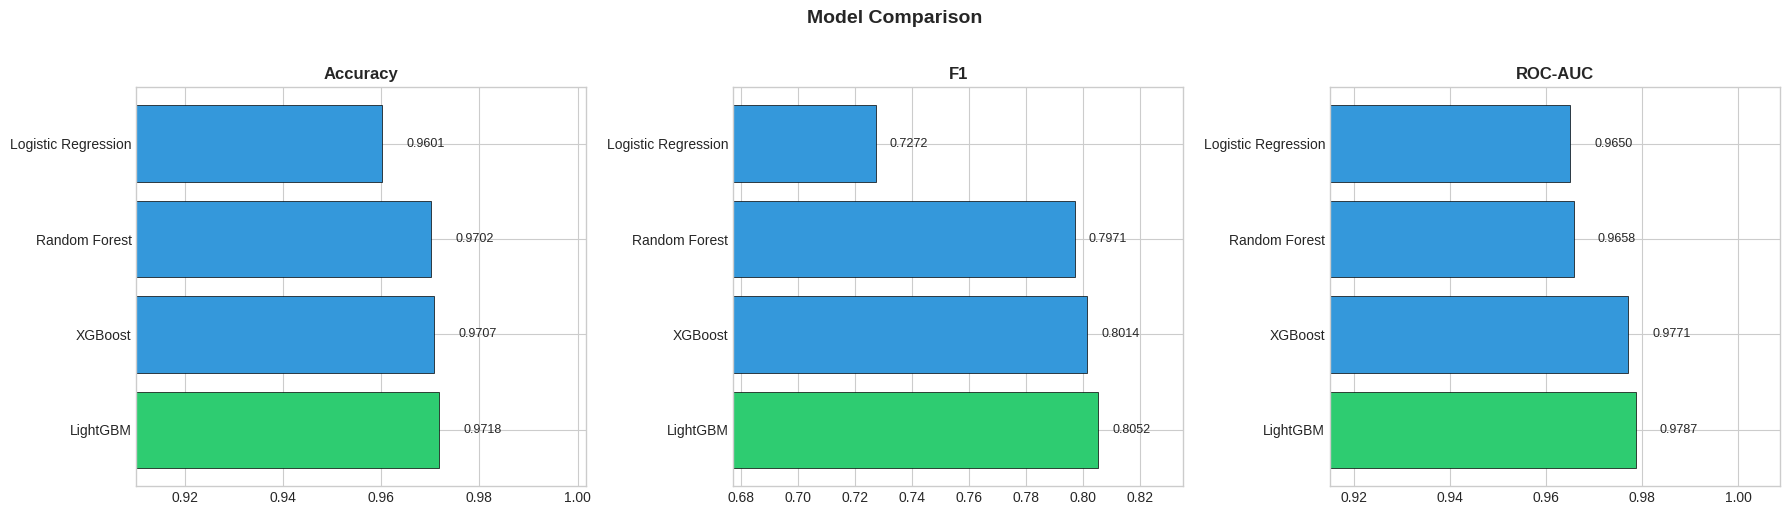

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

For diabetes screening:
- **False negatives** (missed diabetes) = delayed treatment, progression to complications (retinopathy, neuropathy, nephropathy)
- **False positives** (flagging healthy) = unnecessary testing, patient anxiety — but clinically acceptable
- Population screening should bias toward sensitivity (catch more cases)


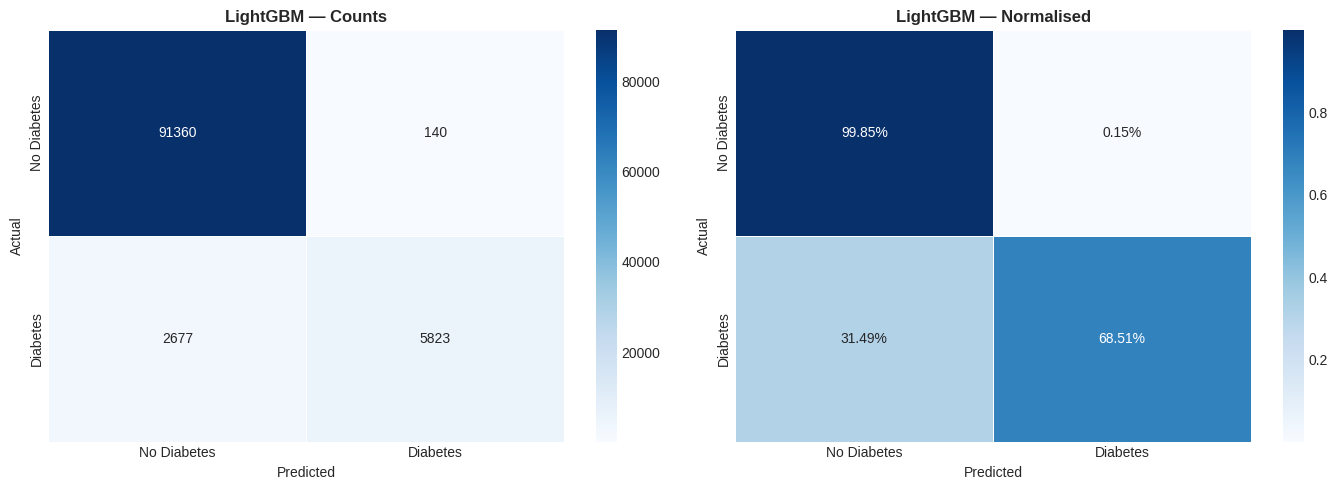


              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     91500
    Diabetes       0.98      0.69      0.81      8500

    accuracy                           0.97    100000
   macro avg       0.97      0.84      0.90    100000
weighted avg       0.97      0.97      0.97    100000



In [15]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['No Diabetes', 'Diabetes']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


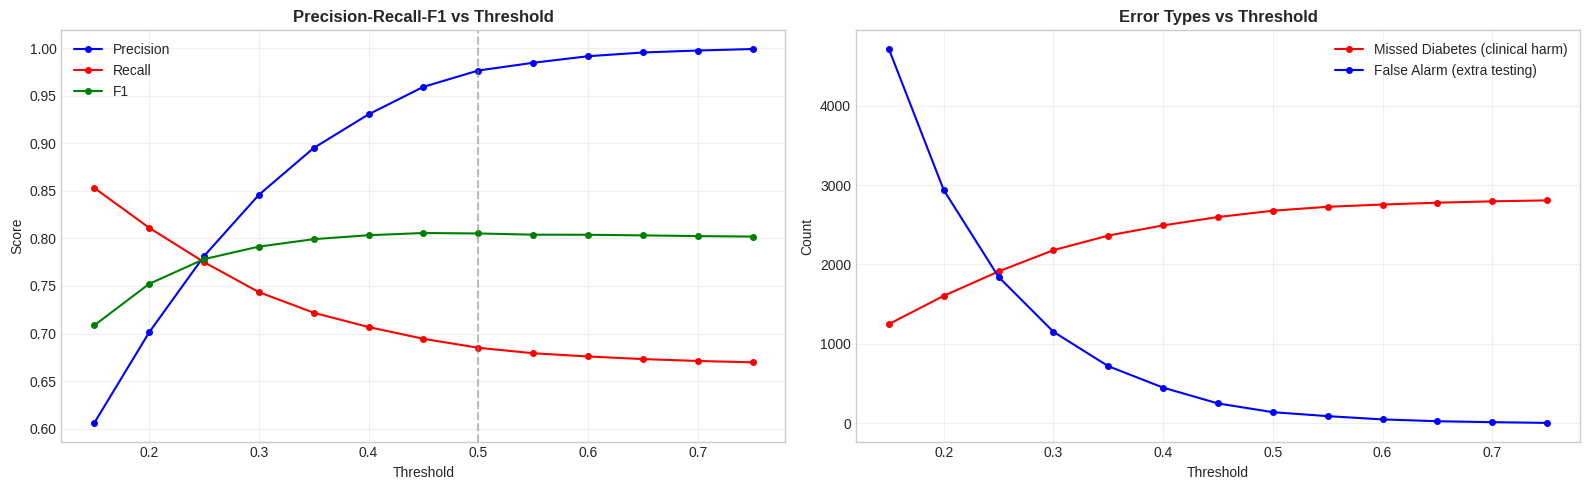


Optimal threshold (F1): 0.45
For population screening, consider lower threshold (0.30-0.40) to maximise sensitivity.


In [16]:
thresholds = np.arange(0.15, 0.80, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed Diabetes (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Alarm (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Diabetes (FN)'], 'r-o', ms=4, label='Missed Diabetes (clinical harm)')
axes[1].plot(thresh_df['Threshold'], thresh_df['False Alarm (FP)'], 'b-o', ms=4, label='False Alarm (extra testing)')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")
print(f"For population screening, consider lower threshold (0.30-0.40) to maximise sensitivity.")


## 8. Feature Importance & Policy Insights

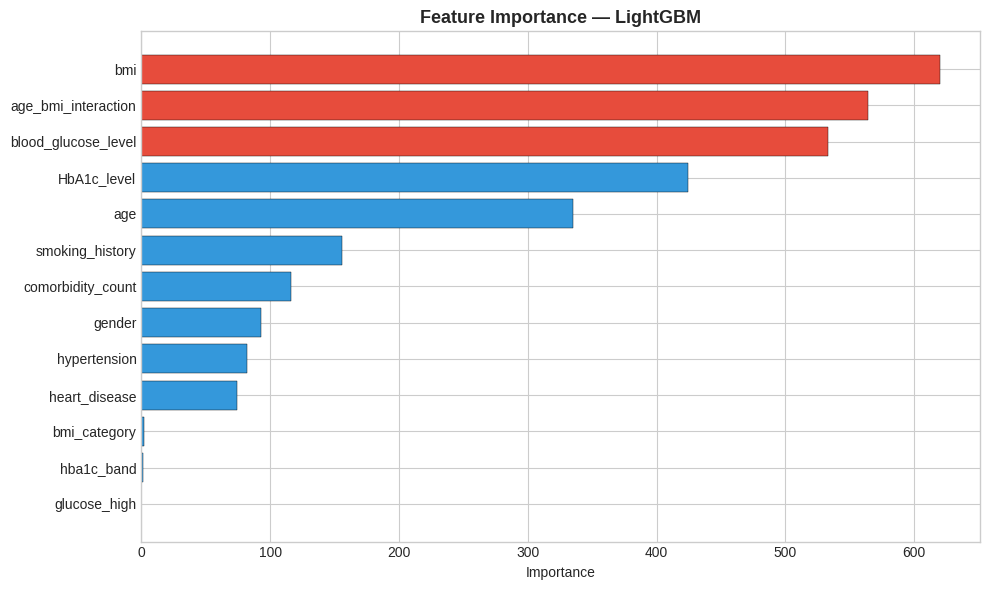

TOP 5 PREDICTIVE FEATURES
  bmi                             620.0000
  age_bmi_interaction             564.0000
  blood_glucose_level             533.0000
  HbA1c_level                     424.0000
  age                             335.0000


In [17]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:30s}  {row['Importance']:.4f}")


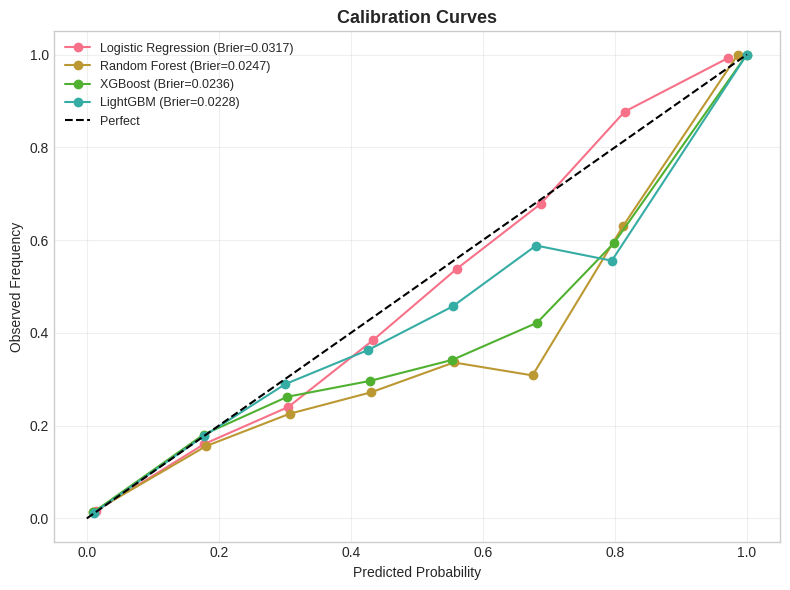

Good calibration essential for clinical use — predicted risk must match actual prevalence.


In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()
print("Good calibration essential for clinical use — predicted risk must match actual prevalence.")


## 9. Deployment Readiness & Production Considerations

In [19]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.80': best_res['auc_mean'] > 0.80,
    'F1 > 0.60': best_res['f1_mean'] > 0.60,
    'Brier < 0.15': best_res['brier_mean'] < 0.15,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    LightGBM
  ROC-AUC:              0.9787
  F1:                   0.8052
  Precision:            0.9766
  Recall:               0.6851
  Brier Score:          0.0228
  Training time:        1.9s
  Feature count:        13
  Dataset rows:         100,000
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.45

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.80
  [pass] F1 > 0.60
  [pass] Brier < 0.15
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [20]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: My Health Record, GP clinical systems (Best Practice/Medical Director)
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (pathology results, vitals, history)
   Schedule: Real-time at GP consultation + quarterly population screening

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) embedded in GP clinical software
   Batch: Quarterly PHN population risk stratification
   Output: Risk score + top contributing factors + recommended action

3. INTEGRATION POINTS
   GP desktop: Risk score in patient summary (Best Practice plugin)
   PHN dashboard: Population health heatmap by LGA
   Medicare: MBS item triggers for health assessments (item 701/703/705)
   My Health Record: Risk score as clinical document
   Patient app: Personalised risk communication + lifestyle goals

4. CLINICAL GOVERNANCE
   TGA: Software as Medical Device (SaMD) classification
   Clinical validation: Prospective study with endocrinology review
   Explainability: SHAP values for every prediction (clinician trust)
   Consent: Patient informed consent for ML-assisted screening
   Equity: Monitor for bias across Indigenous, CALD, rural populations
   RACGP: Alignment with Guidelines for Preventive Activities

5. MONITORING & RETRAINING
   Drift: PSI on pathology distributions quarterly
   Performance: AUC on confirmed diagnoses (6-month follow-up)
   Retraining: Annual with updated pathology-confirmed outcomes
   Clinical validation: Ongoing sensitivity/specificity vs GP diagnosis
   Population shift: Aging population, obesity trends, demographic change

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: My Health Record, GP clinical systems (Best Practice/Medical Director)
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (pathology results, vitals, history)
   Schedule: Real-time at GP consultation + quarterly population screening

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) embedded in GP clinical software
   Batch: Quarterly PHN population risk stratification
   Output: Risk score + top contributing factors + recommended action

3. INTEGRATION POINTS
   GP desktop: Risk score in patient summary (Best Practice plugin)
   PHN dashboard: Population health heatmap by LGA
   Medicare: MBS item triggers for health assessments (item 701/703/705)
   My Health Record: Risk score as clinical document
   Patient app: Personalised risk communication + lifestyle goals

4. CLINICAL GOVERNANCE
   TGA: Software as Medical Device (SaMD) cl